# 🕸️ Aprendendo Análise de Redes Sociais com Python

Este notebook é um **tutorial passo a passo** para quem quer aprender a analisar e visualizar redes de amizade.

Vamos usar dados **reais** de redes do Facebook (ego-networks) que já estão neste projeto.

### O que você vai aprender:
1. Como carregar dados de amizade (pares de amigos)
2. Como construir um **grafo** (rede) com esses dados
3. Como **visualizar** quem é amigo de quem
4. Como calcular métricas: quem tem mais amigos, caminhos entre pessoas
5. Como identificar **grupos/comunidades** dentro da rede

---
> **Conceito básico:** Um grafo de amizade é feito de **nós** (pessoas) e **arestas** (conexões). Se A é amigo de B, existe uma aresta ligando A e B.

## 📦 Parte 1 — Importar as Bibliotecas

Antes de tudo, precisamos instalar e importar as ferramentas certas:

| Biblioteca | Para que serve |
|---|---|
| `networkx` | Criar e analisar grafos (redes) |
| `matplotlib` | Desenhar gráficos e visualizações |
| `pandas` | Manipular tabelas de dados |
| `numpy` | Operações matemáticas |

In [1]:
# Se ainda não tiver instalado, descomente e rode a linha abaixo:
# !pip install networkx matplotlib pandas numpy

import networkx as nx          # grafo
import matplotlib.pyplot as plt # visualização
import matplotlib.colors as mcolors
import pandas as pd             # tabelas
import numpy as np              # matemática
import os

print("✅ Bibliotecas carregadas com sucesso!")
print(f"   NetworkX  versão: {nx.__version__}")
print(f"   Pandas    versão: {pd.__version__}")
print(f"   Matplotlib versão: {plt.matplotlib.__version__}")

✅ Bibliotecas carregadas com sucesso!
   NetworkX  versão: 3.6.1
   Pandas    versão: 3.0.1
   Matplotlib versão: 3.10.8


## 🧑‍🤝‍🧑 Parte 2 — Exemplo Simples: Criando Dados de Amizade na Mão

Antes de usar os dados reais, vamos entender o conceito com um exemplo pequeno.

Imagine um grupo de 6 amigos. Cada linha abaixo representa "A é amigo de B":

```
Alice  — Bob
Alice  — Carol
Bob    — David
Carol  — David
David  — Eve
Eve    — Frank
Frank  — Alice
```

Vamos representar isso como uma tabela (DataFrame) e depois construir o grafo.

In [2]:
# Criando a tabela de amizades manualmente
amizades_simples = pd.DataFrame({
    'pessoa_a': ['Alice', 'Alice', 'Bob',   'Carol', 'David', 'Eve',   'Frank'],
    'pessoa_b': ['Bob',   'Carol', 'David', 'David', 'Eve',   'Frank', 'Alice']
})

print("Tabela de amizades:")
print(amizades_simples.to_string(index=False))
print(f"\nTotal de conexões: {len(amizades_simples)}")

Tabela de amizades:
pessoa_a pessoa_b
   Alice      Bob
   Alice    Carol
     Bob    David
   Carol    David
   David      Eve
     Eve    Frank
   Frank    Alice

Total de conexões: 7


## 🔨 Parte 3 — Construindo o Grafo

Um **grafo não-direcionado** significa que a amizade é mútua (se A é amigo de B, B também é amigo de A).

- `G.nodes()` → lista de todas as pessoas
- `G.edges()` → lista de todas as conexões

In [3]:
# Criando um grafo não-direcionado (amizade é mútua)
G_simples = nx.Graph()

# Adicionando todas as arestas a partir do DataFrame
# nx.from_pandas_edgelist faz isso de forma conveniente:
G_simples = nx.from_pandas_edgelist(amizades_simples, source='pessoa_a', target='pessoa_b')

print(f"Número de pessoas (nós):     {G_simples.number_of_nodes()}")
print(f"Número de amizades (arestas): {G_simples.number_of_edges()}")
print(f"\nPessoas na rede: {sorted(G_simples.nodes())}")
print(f"\nConexões:        {list(G_simples.edges())}")

Número de pessoas (nós):     6
Número de amizades (arestas): 7

Pessoas na rede: ['Alice', 'Bob', 'Carol', 'David', 'Eve', 'Frank']

Conexões:        [('Alice', 'Bob'), ('Alice', 'Carol'), ('Alice', 'Frank'), ('Bob', 'David'), ('Carol', 'David'), ('David', 'Eve'), ('Eve', 'Frank')]


## 🎨 Parte 4 — Visualizando a Rede de Amizade

Vamos desenhar o grafo! O NetworkX tem vários **layouts** (formas de posicionar os nós):

- `spring_layout` → força física, amigos ficam mais próximos (mais intuitivo)
- `circular_layout` → todos em círculo
- `kamada_kawai_layout` → minimiza cruzamento de arestas

Vamos comparar os dois principais:

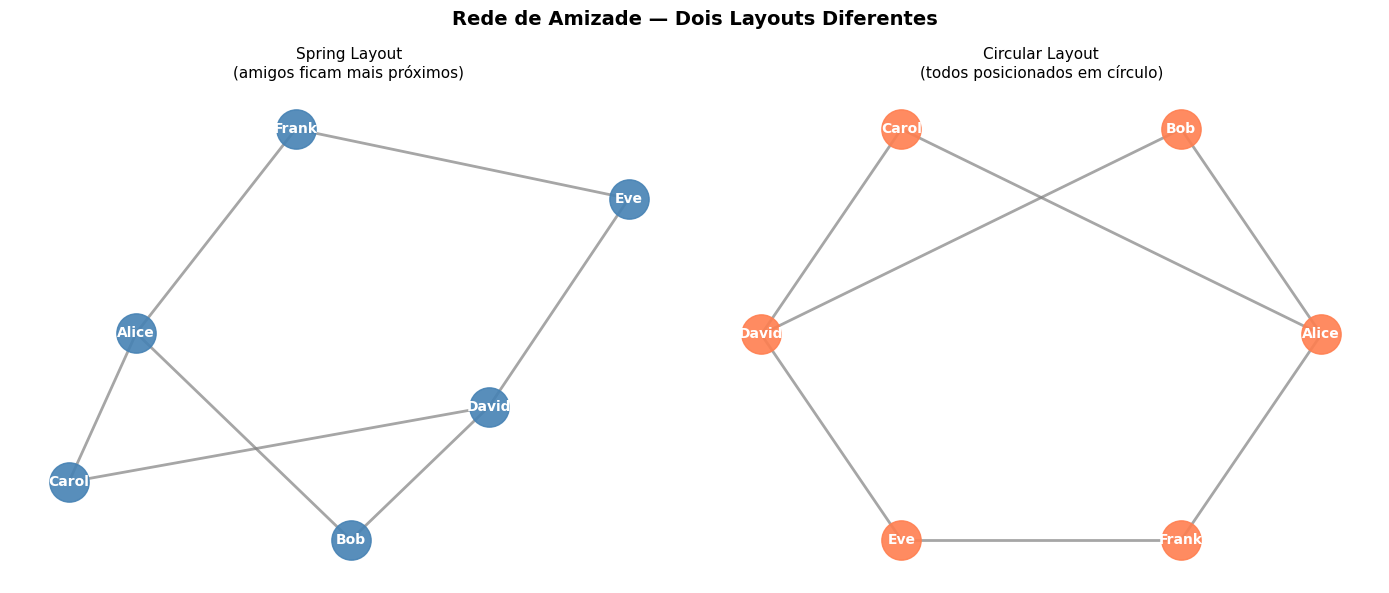

💾 Imagem salva em data/generated/rede_simples.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Rede de Amizade — Dois Layouts Diferentes", fontsize=14, fontweight='bold')

# --- Layout 1: Spring (força física) ---
pos_spring = nx.spring_layout(G_simples, seed=42)  # seed=42 para reproduzir sempre igual
ax1 = axes[0]
ax1.set_title("Spring Layout\n(amigos ficam mais próximos)", fontsize=11)

nx.draw_networkx_nodes(G_simples, pos_spring, ax=ax1,
                       node_color='steelblue', node_size=800, alpha=0.9)
nx.draw_networkx_edges(G_simples, pos_spring, ax=ax1,
                       edge_color='gray', width=2, alpha=0.7)
nx.draw_networkx_labels(G_simples, pos_spring, ax=ax1,
                        font_size=10, font_color='white', font_weight='bold')
ax1.set_axis_off()

# --- Layout 2: Circular ---
pos_circ = nx.circular_layout(G_simples)
ax2 = axes[1]
ax2.set_title("Circular Layout\n(todos posicionados em círculo)", fontsize=11)

nx.draw_networkx_nodes(G_simples, pos_circ, ax=ax2,
                       node_color='coral', node_size=800, alpha=0.9)
nx.draw_networkx_edges(G_simples, pos_circ, ax=ax2,
                       edge_color='gray', width=2, alpha=0.7)
nx.draw_networkx_labels(G_simples, pos_circ, ax=ax2,
                        font_size=10, font_color='white', font_weight='bold')
ax2.set_axis_off()

plt.tight_layout()
plt.savefig('../data/generated/rede_simples.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Imagem salva em data/generated/rede_simples.png")

## 📊 Parte 5 — Analisando Métricas da Rede

Agora vamos entender **quem é quem** na rede através de métricas:

| Métrica | Significado |
|---|---|
| **Grau (degree)** | Quantos amigos uma pessoa tem |
| **Centralidade de grau** | Grau normalizado (0 a 1) |
| **Centralidade de intermediação** | Quanto uma pessoa "conecta" outros grupos |
| **Caminho mais curto** | Quantos "saltos" separar duas pessoas |

In [5]:
# --- Grau: número de amigos ---
graus = dict(G_simples.degree())

# --- Centralidade de grau (normalizado 0 a 1) ---
centralidade_grau = nx.degree_centrality(G_simples)

# --- Centralidade de intermediação: quem é a "ponte" entre grupos ---
centralidade_entre = nx.betweenness_centrality(G_simples)

# Montando a tabela de resultados
df_metricas = pd.DataFrame({
    'Pessoa':           list(graus.keys()),
    'Nº de Amigos':     list(graus.values()),
    'Centralidade (%)': [round(v * 100, 1) for v in centralidade_grau.values()],
    'Intermediação':    [round(v, 3) for v in centralidade_entre.values()],
}).sort_values('Nº de Amigos', ascending=False)

print("📋 Tabela de métricas por pessoa:")
print(df_metricas.to_string(index=False))

📋 Tabela de métricas por pessoa:
Pessoa  Nº de Amigos  Centralidade (%)  Intermediação
 Alice             3              60.0           0.25
 David             3              60.0           0.25
   Bob             2              40.0           0.05
 Carol             2              40.0           0.05
   Eve             2              40.0           0.10
 Frank             2              40.0           0.10


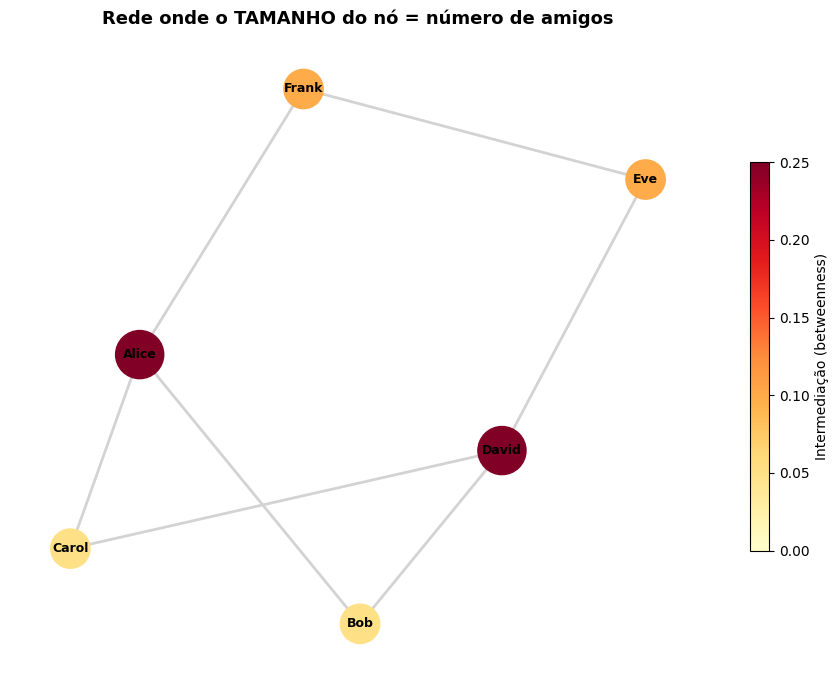

💡 Quem tem nó maior = tem mais amigos; cor mais escura = conecta mais grupos


In [6]:
# --- Visualização: tamanho do nó proporcional ao número de amigos ---
plt.figure(figsize=(9, 7))
plt.title("Rede onde o TAMANHO do nó = número de amigos", fontsize=13, fontweight='bold')

pos = nx.spring_layout(G_simples, seed=42)

# Tamanho proporcional ao grau
tamanhos = [graus[no] * 400 for no in G_simples.nodes()]

# Cor proporcional à intermediação (mais escuro = mais "ponte")
cores = [centralidade_entre[no] for no in G_simples.nodes()]

nx.draw_networkx_edges(G_simples, pos, edge_color='lightgray', width=2)
sc = nx.draw_networkx_nodes(G_simples, pos, node_size=tamanhos, node_color=cores,
                             cmap=plt.cm.YlOrRd, vmin=0, vmax=max(cores))
nx.draw_networkx_labels(G_simples, pos, font_size=9, font_weight='bold')

plt.colorbar(sc, label='Intermediação (betweenness)', shrink=0.6)
plt.axis('off')
plt.tight_layout()
plt.show()
print("💡 Quem tem nó maior = tem mais amigos; cor mais escura = conecta mais grupos")

## 🏘️ Parte 6 — Encontrando Comunidades (Grupos de Amigos)

**Detecção de comunidade** é o processo de encontrar grupos de pessoas que têm mais conexões entre si do que com o resto.

É como encontrar "panelinhas" dentro de uma turma!

Vamos usar o algoritmo de **Girvan-Newman** (clássico) e o **Louvain** (moderno):

> O algoritmo funciona identificando e removendo as arestas que conectam comunidades diferentes, até o grafo se dividir em grupos.

Número de comunidades encontradas: 2
  Grupo 1: ['Alice', 'Bob', 'Carol', 'David']
  Grupo 2: ['Eve', 'Frank']


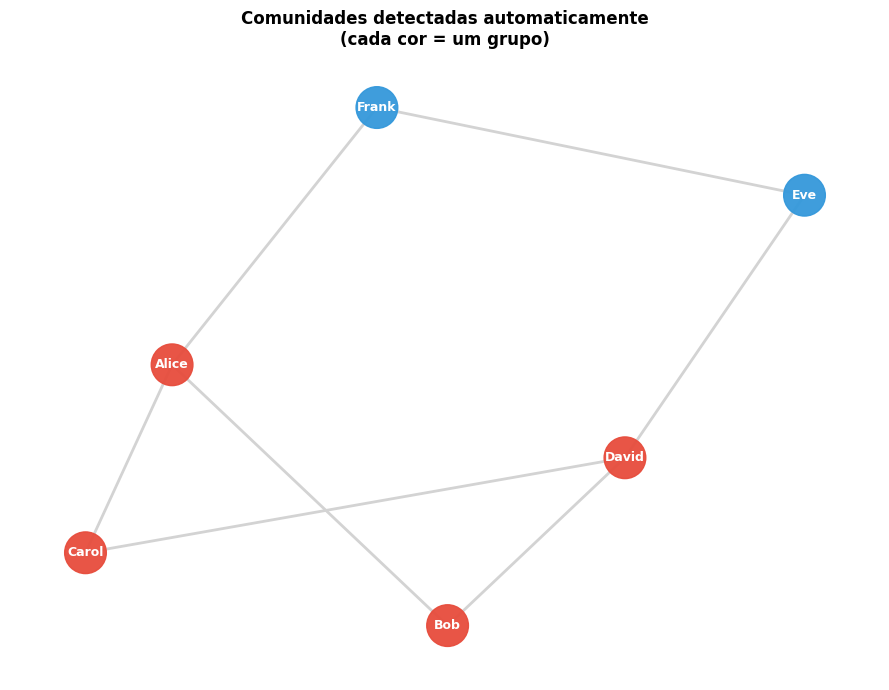

In [8]:
from networkx.algorithms.community import greedy_modularity_communities

# Detecta comunidades com o algoritmo de modularidade gulosa
comunidades = list(greedy_modularity_communities(G_simples))

print(f"Número de comunidades encontradas: {len(comunidades)}")
for i, c in enumerate(comunidades):
    print(f"  Grupo {i+1}: {sorted(c)}")

# Visualizando com cores diferentes por comunidade
cores_paleta = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
cor_no = {}
for i, comunidade in enumerate(comunidades):
    for pessoa in comunidade:
        cor_no[pessoa] = cores_paleta[i % len(cores_paleta)]

lista_cores = [cor_no[n] for n in G_simples.nodes()]

plt.figure(figsize=(9, 7))
plt.title("Comunidades detectadas automaticamente\n(cada cor = um grupo)", fontsize=12, fontweight='bold')

pos = nx.spring_layout(G_simples, seed=42)
nx.draw_networkx_edges(G_simples, pos, edge_color='lightgray', width=2)
nx.draw_networkx_nodes(G_simples, pos, node_color=lista_cores, node_size=900, alpha=0.95)
nx.draw_networkx_labels(G_simples, pos, font_size=9, font_weight='bold', font_color='white')

plt.axis('off')
plt.tight_layout()
plt.show()

---

## 🌐 Parte 7 — Dados Reais: Facebook Ego-Network

Agora vamos usar dados **reais** de redes sociais do Facebook!

Os arquivos `.edges` na pasta `data/facebook/` contêm pares de usuários conectados. Cada linha `A B` significa que o usuário `A` e o usuário `B` são amigos.

Vamos carregar a rede do **ego 107** — uma subrede com centenas de usuários reais (anonimizados):

> **O que é uma ego-network?** É a rede de amigos de uma pessoa central ("ego"), incluindo as amizades entre eles.

In [9]:
# Carregando dados reais do Facebook
FACEBOOK_DIR = '../data/facebook/'
EGO_ID = '107'  # Experimente mudar para: '0', '1684', '1912', '348', '414', '686', '698'

edges_file = os.path.join(FACEBOOK_DIR, f'{EGO_ID}.edges')

# Lendo o arquivo de arestas (cada linha: "u v")
df_facebook = pd.read_csv(edges_file, sep=' ', header=None, names=['u', 'v'])

print(f"Ego-network {EGO_ID} carregada!")
print(f"  Linhas no arquivo:     {len(df_facebook)}")
print(f"\nPrimeiras conexões:")
print(df_facebook.head(10).to_string(index=False))

Ego-network 107 carregada!
  Linhas no arquivo:     53498

Primeiras conexões:
   u    v
 953 1323
1789 1707
1175 1059
1329 1559
1804 1898
1622 1520
1200 1202
1449 1836
1156 1605
1149 1559


In [10]:
# Construindo o grafo real
G_fb = nx.from_pandas_edgelist(df_facebook, source='u', target='v')

print(f"Grafo da ego-network {EGO_ID}:")
print(f"  Pessoas (nós):        {G_fb.number_of_nodes()}")
print(f"  Amizades (arestas):   {G_fb.number_of_edges()}")
print(f"  Grau médio:           {2 * G_fb.number_of_edges() / G_fb.number_of_nodes():.1f} amigos")
print(f"  Conectado?            {'Sim ✅' if nx.is_connected(G_fb) else 'Não (há grupos isolados) ⚠️'}")

# Top 5 pessoas com mais amigos
graus_fb = dict(G_fb.degree())
top5 = sorted(graus_fb.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\nTop 5 pessoas mais conectadas:")
for pessoa, grau in top5:
    print(f"  Usuário {pessoa}: {grau} amigos")

Grafo da ego-network 107:
  Pessoas (nós):        1034
  Amizades (arestas):   26749
  Grau médio:           51.7 amigos
  Conectado?            Sim ✅

Top 5 pessoas mais conectadas:
  Usuário 1888: 253 amigos
  Usuário 1800: 244 amigos
  Usuário 1663: 234 amigos
  Usuário 1352: 233 amigos
  Usuário 1730: 225 amigos


In [ ]:
# Visualizando a rede real — com cores por número de amigos
print("Gerando visualização do grafo real (pode demorar alguns segundos)...")

plt.figure(figsize=(14, 12))
plt.title(f"Facebook Ego-Network {EGO_ID}\n"
          f"{G_fb.number_of_nodes()} pessoas, {G_fb.number_of_edges()} amizades",
          fontsize=14, fontweight='bold')

# Layout (spring é bom para ver comunidades)
pos_fb = nx.spring_layout(G_fb, seed=42, k=0.3)

graus_fb_dict = dict(G_fb.degree())

# Cor e tamanho proporcional ao grau
cores_fb  = [graus_fb_dict[n] for n in G_fb.nodes()]
tamanhos_fb = [max(30, graus_fb_dict[n] * 8) for n in G_fb.nodes()]

nx.draw_networkx_edges(G_fb, pos_fb, alpha=0.15, edge_color='gray', width=0.5)
sc = nx.draw_networkx_nodes(G_fb, pos_fb, node_size=tamanhos_fb,
                             node_color=cores_fb, cmap=plt.cm.plasma, alpha=0.85)

# Destacar apenas os 5 mais conectados com labels
top5_nos = [n for n, _ in top5]
labels_top5 = {n: str(n) for n in top5_nos}
nx.draw_networkx_labels(G_fb, pos_fb, labels=labels_top5, font_size=8,
                        font_color='white', font_weight='bold')

plt.colorbar(sc, label='Número de amigos', shrink=0.6)
plt.axis('off')
plt.tight_layout()
plt.savefig('../data/generated/rede_facebook.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Salvo em data/generated/rede_facebook.png")
print("💡 Nós maiores e mais brilhantes = mais amigos")

## 📈 Parte 8 — Distribuição de Graus (Histograma de Amigos)

Uma análise clássica em redes sociais é ver a **distribuição de graus**: 
quantas pessoas têm 1 amigo, 2 amigos, 10 amigos, etc.

Redes reais geralmente seguem uma **lei de potência** (power law): poucas pessoas têm muitos amigos, e a maioria tem poucos. Esse formato é chamado de "cauda longa".

In [ ]:
lista_graus = sorted([d for _, d in G_fb.degree()], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Distribuição de Graus — Facebook Ego {EGO_ID}", fontsize=13, fontweight='bold')

# --- Histograma normal ---
ax1 = axes[0]
ax1.set_title("Histograma de graus (linear)")
ax1.hist(lista_graus, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax1.set_xlabel("Número de amigos")
ax1.set_ylabel("Quantidade de pessoas")
ax1.axvline(np.mean(lista_graus), color='red', linestyle='--',
            label=f'Média: {np.mean(lista_graus):.1f}')
ax1.legend()

# --- Escala log-log para ver "lei de potência" ---
from collections import Counter
contagem = Counter(lista_graus)
xs = sorted(contagem.keys())
ys = [contagem[x] for x in xs]

ax2 = axes[1]
ax2.set_title("Distribuição log-log\n(lei de potência?)")
ax2.scatter(xs, ys, alpha=0.6, color='coral', s=30)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel("Número de amigos (log)")
ax2.set_ylabel("Frequência (log)")

plt.tight_layout()
plt.show()

print(f"Estatísticas:")
print(f"  Grau mínimo:  {min(lista_graus)}")
print(f"  Grau máximo:  {max(lista_graus)}")
print(f"  Grau médio:   {np.mean(lista_graus):.1f}")
print(f"  Mediana:      {np.median(lista_graus):.0f}")

## 💾 Parte 9 — Exportando o Grafo

Você pode salvar o grafo em vários formatos para usar em outras ferramentas:

| Formato | Uso |
|---|---|
| **GraphML** | Gephi, yEd, Cytoscape |
| **JSON** | Visualizações web (D3.js, vis.js) |
| **GML** | Muitas ferramentas de análise |

In [ ]:
import json
from networkx.readwrite import json_graph

os.makedirs('../data/generated', exist_ok=True)

# 1. Exportar como GraphML (para Gephi, etc.)
graphml_path = f'../data/generated/facebook_{EGO_ID}.graphml'
nx.write_graphml(G_fb, graphml_path)
print(f"✅ GraphML salvo em: {graphml_path}")

# 2. Exportar como JSON (para D3.js, etc.)
json_path = f'../data/generated/facebook_{EGO_ID}_grafo.json'
data_json = json_graph.node_link_data(G_fb)
with open(json_path, 'w') as f:
    json.dump(data_json, f, indent=2)
print(f"✅ JSON   salvo em: {json_path}")

# 3. Exportar lista de arestas como CSV
csv_path = f'../data/generated/facebook_{EGO_ID}_arestas.csv'
df_facebook.to_csv(csv_path, index=False)
print(f"✅ CSV    salvo em: {csv_path}")

# Mostrar tamanhos dos arquivos
for path in [graphml_path, json_path, csv_path]:
    size_kb = os.path.getsize(path) / 1024
    print(f"   {os.path.basename(path)}: {size_kb:.1f} KB")

---

## 🎓 Resumo do que você aprendeu

| Conceito | Ferramenta | O que faz |
|---|---|---|
| Grafo não-direcionado | `nx.Graph()` | Modela amizades mútuas |
| Carregar dados | `nx.from_pandas_edgelist()` | Constrói grafo a partir de tabela |
| Visualizar | `nx.draw_networkx()` | Desenha a rede |
| Layouts | `spring_layout`, `circular_layout` | Posicionamento dos nós |
| Grau | `G.degree()` | Número de amigos |
| Centralidade | `nx.degree_centrality()` | Importância normalizada |
| Intermediação | `nx.betweenness_centrality()` | Quem conecta grupos |
| Caminho | `nx.shortest_path()` | Menor caminho entre dois nós |
| Comunidades | `greedy_modularity_communities()` | Detecta grupos automático |
| Exportar | `nx.write_graphml()` | Salva para outras ferramentas |

### 🚀 Próximos passos sugeridos:
1. Experimente mudar `EGO_ID` para `'1684'` ou `'1912'` (redes maiores)
2. Tente encontrar "six degrees of separation" entre dois usuários aleatórios
3. Instale o **Gephi** (gratuito) e abra o arquivo `.graphml` gerado para uma visualização interativa
4. Explore a biblioteca **pyvis** para grafos interativos no browser